In [32]:
import pandas as pd
import numpy as np

import chess
import stockfish as st

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("data.csv")

prev = df.shape[0]
print("with duplicates", prev)
df.drop_duplicates(inplace=True, subset=["FEN", "Moves"])
print("without duplicates", df.shape[0])
print(f"dropped {prev-df.shape[0]}")

with duplicates 4557000
without duplicates 4556924
dropped 76


Были найдены утечки в тренировочном дс, пришлось почистить

Так же был обнаружен забавный факт, есть целых 3 тыс. задач, где одинаковая позиция, но разные решения. Это наталкивает на мысль, что вероятностные предсказания движка могут быть неверными просто потому, что решение может отличаться от лучшего хода (Списываю на то, что решения для головоломок были расчитаны более слабым движком, чем тот, что оценивал вероятности).

In [4]:
df.columns

Index(['PuzzleId', 'FEN', 'Moves', 'Rating', 'RatingDeviation', 'Popularity',
       'NbPlays', 'Themes', 'GameUrl', 'OpeningTags',
       'success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050'],
      dtype='str')

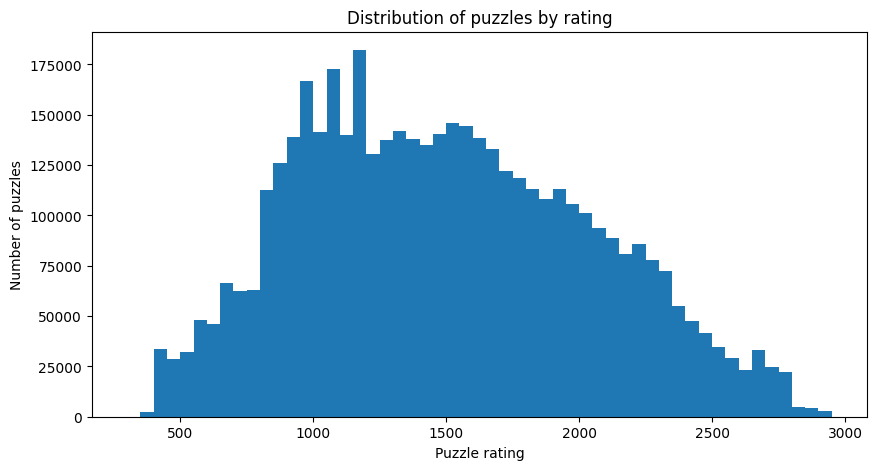

In [61]:
plt.figure(figsize=(10,5))

plt.hist(df["Rating"], bins=np.arange(300,3000,50))

plt.xlabel("Puzzle rating")
plt.ylabel("Number of puzzles")
plt.title("Distribution of puzzles by rating")

plt.show()

# 0. Рассмотрение данных + попытки в статистическое решение
---
Идея этого блока состоит в том, что рейтинг по ELO-системе при достаточном числе итераций будет гарантировать вероятность 0.5 решение игроком задачи своего рейтинга.
В таком случае статистическая информация для задач должна быть достаточной для предсказания рейтинга.

Так как тогда все эти вероятности решения - дискретизация логистической кривой

$$P(r) = \frac{1}{1+\exp{-k(r-d)}}$$

In [5]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

"""
P.S. У этой функции смешной интерфейс, чтобы потом сделать мини-трейн для обучаемого объединения 
результатов для статистики блиц и рапид вместо простого усреднения

"""


class SigmoidPuzzleRegressor:
    def __init__(self):
        self.rating_levels = np.array(
            [1050, 1150, 1250, 1350, 1450, 1550, 1650, 1750, 1850, 1950, 2050],
            dtype=float
        )

    @staticmethod
    def sigmoid(x, r0, k):
        return 1.0 / (1.0 + np.exp(-k * (x - r0)))

    def fit_sigmoid_from_probs(self, probs):
        x = self.rating_levels
        y = np.asarray(probs, dtype=float)

        y = np.clip(y, 1e-6, 1 - 1e-6)

        if y.min() <= 0.5 <= y.max():
            r0_init = np.interp(0.5, y, x)
        else:
            r0_init = x.mean()

        k_init = 0.01

        try:
            popt, _ = curve_fit(
                self.sigmoid,
                x,
                y,
                p0=[r0_init, k_init],
                bounds=([800.0, 1e-5], [3000.0, 1.0]),
                maxfev=10000
            )
            r0, k = popt
            y_fit = self.sigmoid(x, r0, k)
            mse = np.mean((y - y_fit) ** 2)
            return float(r0), float(k), float(mse)
        except Exception:
            return np.nan, np.nan, np.inf

    def predict_one(self, probs):
        probs = np.asarray(probs, dtype=float)

        rapid_probs = probs[:11]
        blitz_probs = probs[11:]

        rapid_r0, rapid_k, rapid_mse = self.fit_sigmoid_from_probs(rapid_probs)
        blitz_r0, blitz_k, blitz_mse = self.fit_sigmoid_from_probs(blitz_probs)

        if np.isfinite(rapid_r0) and np.isfinite(blitz_r0):
            w_rapid = 1.0 / (rapid_mse + 1e-8)
            w_blitz = 1.0 / (blitz_mse + 1e-8)
            rating_pred = (w_rapid * rapid_r0 + w_blitz * blitz_r0) / (w_rapid + w_blitz)
        elif np.isfinite(rapid_r0):
            rating_pred = rapid_r0
        elif np.isfinite(blitz_r0):
            rating_pred = blitz_r0
        else:
            rating_pred = np.nan

        return float(rating_pred)

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = [self.predict_one(row) for row in X]
        return np.array(preds, dtype=float)

In [6]:
def show_sigmoid(row):

    ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

    rapid_cols = [
    'success_prob_rapid_1050','success_prob_rapid_1150','success_prob_rapid_1250',
    'success_prob_rapid_1350','success_prob_rapid_1450','success_prob_rapid_1550',
    'success_prob_rapid_1650','success_prob_rapid_1750','success_prob_rapid_1850',
    'success_prob_rapid_1950','success_prob_rapid_2050'
    ]

    probs = row[rapid_cols].values

    def sigmoid(x, r0, k):
        return 1/(1+np.exp(-k*(x-r0)))

    y = np.clip(probs, 1e-6, 1-1e-6)

    r0_init = np.interp(0.5, y, ratings) if (y.min()<=0.5<=y.max()) else ratings.mean()

    plt.figure(figsize=(7,4))

    plt.scatter(ratings,probs,label="data",s=60)

    try:
        params, _ = curve_fit(
            sigmoid,
            ratings,
            y,
            p0=[r0_init,0.01],
            maxfev=5000
        )

        r0,k = params

        x_dense = np.linspace(1000,2100,400)
        y_fit = sigmoid(x_dense,r0,k)


        plt.plot(x_dense,y_fit,label="sigmoid fit")
    except:
        pass

    plt.xlabel("Player rating")
    plt.ylabel("Success probability")
    plt.title(f"Task rating: {row['Rating']}")

    plt.legend()
    plt.grid(True)

    plt.show()

60


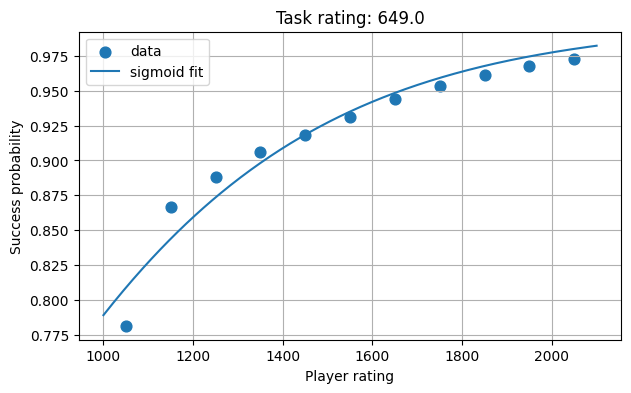

61


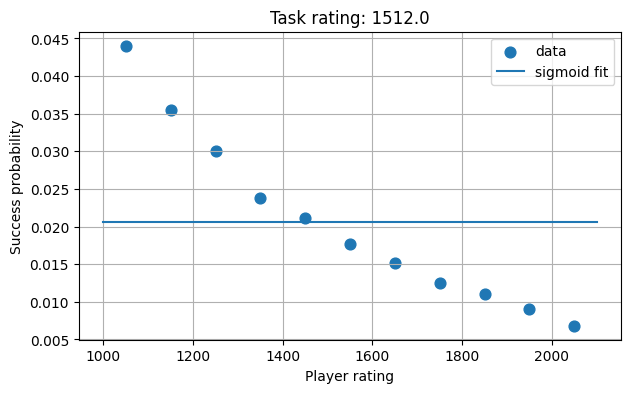

94


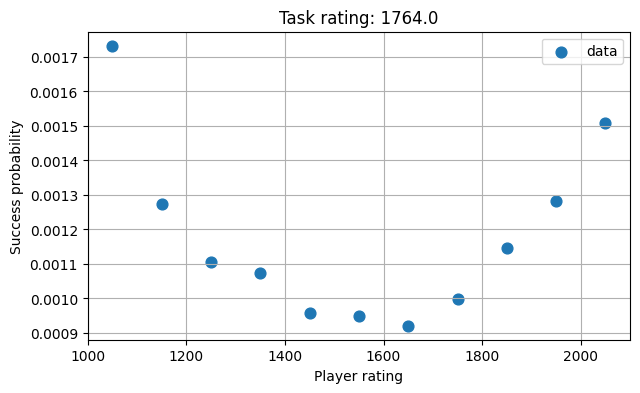

67


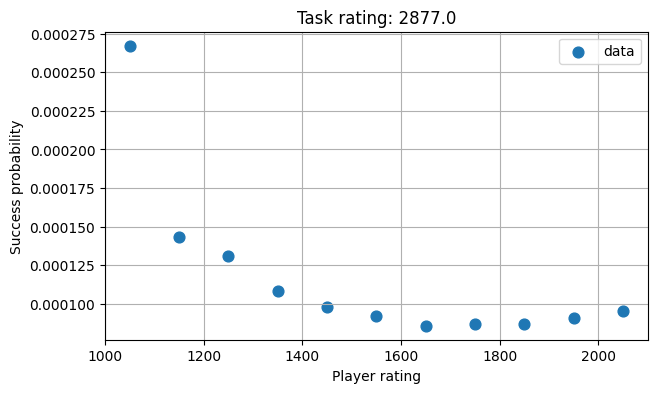

In [7]:
from random import randint
ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

rapid_cols = [
    'success_prob_rapid_1050','success_prob_rapid_1150','success_prob_rapid_1250',
    'success_prob_rapid_1350','success_prob_rapid_1450','success_prob_rapid_1550',
    'success_prob_rapid_1650','success_prob_rapid_1750','success_prob_rapid_1850',
    'success_prob_rapid_1950','success_prob_rapid_2050','Rating'
    ]
dfcut = df[rapid_cols]
for i in [38, 1, 83, 4]:
    x = randint(0, 100)
    row = dfcut.iloc[i]
    print(x)
    show_sigmoid(row)


In [ ]:
feature_cols = [
    'success_prob_rapid_1050', 'success_prob_rapid_1150',
    'success_prob_rapid_1250', 'success_prob_rapid_1350',
    'success_prob_rapid_1450', 'success_prob_rapid_1550',
    'success_prob_rapid_1650', 'success_prob_rapid_1750',
    'success_prob_rapid_1850', 'success_prob_rapid_1950',
    'success_prob_rapid_2050',
    'success_prob_blitz_1050', 'success_prob_blitz_1150',
    'success_prob_blitz_1250', 'success_prob_blitz_1350',
    'success_prob_blitz_1450', 'success_prob_blitz_1550',
    'success_prob_blitz_1650', 'success_prob_blitz_1750',
    'success_prob_blitz_1850', 'success_prob_blitz_1950',
    'success_prob_blitz_2050'
]

df_small = dfcutcutcutcutcutcutcutcutcut.sample(n=100_000, random_state=42)

X = df_small[feature_cols]
y = df_small['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = SigmoidPuzzleRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mask = ~np.isnan(y_pred)
y_test_valid = y_test.iloc[mask]
y_pred_valid = y_pred[mask]

print("R2:", r2_score(y_test_valid, y_pred_valid))
print("MAE:", mean_absolute_error(y_test_valid, y_pred_valid))
print("RMSE:", np.sqrt(mean_squared_error(y_test_valid, y_pred_valid)))

R2: -2.195437210813053
MAE: 785.2966871120186
RMSE: 969.8299976593504


# 1. Выделение ключевых признаков с помощью __Lasso__ и введение __Baseline__
---


In [10]:
dfreg = df[['Rating',
       'success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]
print("full size", dfreg.shape)
dfreg.dropna()
print("size without nans", dfreg.shape)


full size (4557000, 23)
size without nans (4557000, 23)


Посмотрим, насколько хорошо видна корреляция между предсказанными движком вероятностями 

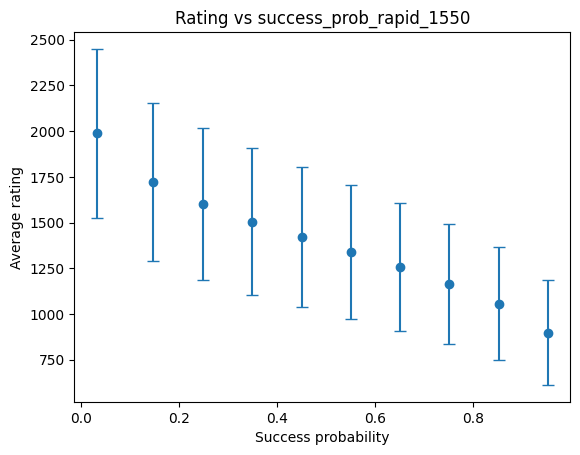

In [ ]:
prob_col = 'success_prob_rapid_1550'
n_bins = 10
dfreg['prob_bin'] = pd.cut(dfreg[prob_col], bins=n_bins)

stats = dfreg.groupby('prob_bin').agg(
    prob_mean=(prob_col, 'mean'),
    rating_mean=('Rating', 'mean'),
    rating_std=('Rating', 'std'),
    count=('Rating', 'size')
).reset_index()

plt.errorbar(
    stats['prob_mean'],
    stats['rating_mean'],
    yerr=stats['rating_std'],
    fmt='o',
    capsize=4
)

plt.xlabel("Success probability")
plt.ylabel("Average task rating")
plt.title(f"Rating vs {prob_col}")

plt.show()

Перейдём к модели

In [18]:
X = df[['success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]

y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=100000)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Best alpha:", model.named_steps['lassocv'].alpha_)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best alpha: 0.3808444241789319
R2: 0.4931134718352346
MAE: 309.42495625637827
RMSE: 387.3266323637934


In [20]:
coef = model.named_steps['lassocv'].coef_

coef = model.named_steps['lassocv'].coef_
for feature, weight in zip(X.columns, coef):
    print(feature, weight)

success_prob_rapid_1050 -0.0
success_prob_rapid_1150 -226.3787518760727
success_prob_rapid_1250 -0.0
success_prob_rapid_1350 -0.0
success_prob_rapid_1450 -46.11950556755898
success_prob_rapid_1550 -0.0
success_prob_rapid_1650 0.0
success_prob_rapid_1750 -0.0
success_prob_rapid_1850 0.0
success_prob_rapid_1950 -0.0
success_prob_rapid_2050 -30.157258659582414
success_prob_blitz_1050 -144.34280691834618
success_prob_blitz_1150 -0.0
success_prob_blitz_1250 0.0
success_prob_blitz_1350 0.0
success_prob_blitz_1450 0.0
success_prob_blitz_1550 138.4177040074611
success_prob_blitz_1650 -0.0
success_prob_blitz_1750 0.0
success_prob_blitz_1850 0.0
success_prob_blitz_1950 0.0
success_prob_blitz_2050 -81.05635115017259


In [23]:
coef_series = pd.Series(coef, index=X.columns)

nonzero = coef_series[coef_series != 0]
selected_features = nonzero.index.tolist()
print(selected_features)

['success_prob_rapid_1150', 'success_prob_rapid_1450', 'success_prob_rapid_2050', 'success_prob_blitz_1050', 'success_prob_blitz_1550', 'success_prob_blitz_2050']


Для лучшего линейного результата воспользуемся __Ridge__

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df[['success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]

y = df['Rating']

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 50))
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Best alpha:", model.named_steps['ridgecv'].alpha_)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best alpha: 0.0517947467923121
R2: 0.5087312878550785
MAE: 303.72139159624925
RMSE: 381.31293545056934


О да, __Ridge__ лучше целых на 6 RMSE. Будем использовать этот результат как Baseline

# Forest

1. Так как я умру от старости, пока лес переварит все данные, буду учить на подвыборке
2. Нужно придумать новые признаки, начнём с очевидных:
      1. Средняя вероятность - обычно очень хорошо для деревьев 
      2. Разница между блиц и рапид должна показать, насколько задача нетиповая и требовательна к глубине размышлений (т.к. игроки в блиц обычно сильно ограничены во времени, поэтому они более чуствительны к длинне задачи)
      3. Градиент по уровню игры
      4. Число ходов из решения
      5. Число фигур на поле


In [92]:
def count_pieces(fen):
    board_part = fen.split()[0]
    return sum(1 for ch in board_part if ch.isalpha())

def solution_length(moves):
    return len(moves.split())

In [80]:
dfcut = df.sample(n=500_000)

rapid_cols = [
    'success_prob_rapid_1050', 'success_prob_rapid_1150', 'success_prob_rapid_1250',
    'success_prob_rapid_1350', 'success_prob_rapid_1450', 'success_prob_rapid_1550',
    'success_prob_rapid_1650', 'success_prob_rapid_1750', 'success_prob_rapid_1850',
    'success_prob_rapid_1950', 'success_prob_rapid_2050'
]

blitz_cols = [
    'success_prob_blitz_1050', 'success_prob_blitz_1150', 'success_prob_blitz_1250',
    'success_prob_blitz_1350', 'success_prob_blitz_1450', 'success_prob_blitz_1550',
    'success_prob_blitz_1650', 'success_prob_blitz_1750', 'success_prob_blitz_1850',
    'success_prob_blitz_1950', 'success_prob_blitz_2050'
]

all_prob_cols = rapid_cols + blitz_cols

# AVG
dfcut['mean_prob_all'] = dfcut[all_prob_cols].mean(axis=1)
dfcut['mean_prob_rapid'] = dfcut[rapid_cols].mean(axis=1)
dfcut['mean_prob_blitz'] = dfcut[blitz_cols].mean(axis=1)

# Diff players
dfcut['gap_prob_mean'] = dfcut['mean_prob_rapid'] - dfcut['mean_prob_blitz']

# Grad
dfcut['grad_rapid'] = dfcut['success_prob_rapid_2050'] - dfcut['success_prob_rapid_1050']
dfcut['grad_blitz'] = dfcut['success_prob_blitz_2050'] - dfcut['success_prob_blitz_1050']

# board info
dfcut["piece_count"] = dfcut["FEN"].apply(count_pieces)
dfcut["solution_length"] = dfcut["Moves"].apply(solution_length)


In [81]:
selected_features = [
    'success_prob_rapid_1150', 'success_prob_rapid_1450', 'success_prob_rapid_2050', 
    'success_prob_blitz_1050', 'success_prob_blitz_1550', 'success_prob_blitz_2050',
    'mean_prob_all', 'mean_prob_rapid', 'mean_prob_blitz',
    'gap_prob_mean',
    'grad_rapid', 'grad_blitz',
    "piece_count", "solution_length"
                      ]
print(f"Currently {len(selected_features)} are chosen")

X = dfcut[selected_features]

y = dfcut['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Currently 14 are chosen


In [83]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.5616498844088195
MAE: 286.9474235778938
RMSE: 361.59043344951596


In [46]:
results = X_test.copy()

results["true_rating"] = y_test.values
results["pred_rating"] = y_pred

results["error"] = results["pred_rating"] - results["true_rating"]
results["abs_error"] = results["error"].abs()

In [84]:
best = results.sort_values("abs_error").head(10)

best[["true_rating", "pred_rating", "abs_error"]]

,true_rating,pred_rating,abs_error
879209,1773,1773.004404,0.004404
1852057,1830,1829.993412,0.006588
3829849,1685,1684.992887,0.007113
2258025,2037,2036.986510,0.013490
3644467,2066,2065.983418,0.016582
1845766,956,955.983275,0.016725
4378679,1063,1062.978087,0.021913
857184,1333,1333.030833,0.030833
1845932,1716,1715.965234,0.034766
3786942,1011,1010.964012,0.035988


In [48]:
worst = results.sort_values("abs_error", ascending=False).head(10)

worst[["true_rating", "pred_rating", "abs_error"]]

,true_rating,pred_rating,abs_error
2331482,2799,1128.452866,1670.547134
2603095,2700,1162.577308,1537.422692
2475930,2896,1370.581100,1525.418900
1687800,2767,1262.306137,1504.693863
891207,604,2105.648088,1501.648088
3379668,2739,1259.189185,1479.810815
4006072,621,2089.772252,1468.772252
590298,2581,1112.290190,1468.709810
1267731,2948,1523.924171,1424.075829
1835021,2784,1364.059217,1419.940783


In [73]:
X_test.loc[891207]

success_prob_rapid_1150     0.033856
success_prob_rapid_1450     0.032588
success_prob_rapid_2050     0.038712
success_prob_blitz_1050     0.032621
success_prob_blitz_1550     0.033570
success_prob_blitz_2050     0.048216
mean_prob_all               0.034778
mean_prob_rapid             0.033721
mean_prob_blitz             0.035836
gap_prob_mean              -0.002115
grad_rapid                  0.005957
grad_blitz                  0.015595
piece_count                12.000000
solution_length             6.000000
Name: 891207, dtype: float64

Выше посмотрели на худшие результаты предсказания модели, как видим, эти данные по большей части представляют собой неадекватные выбросы, так как задача с долей решаемости 0.03 не может иметь рейтинг 600, это даже тяжело списать на недостаточную сходимость рейтинга, ведь он стартует с 1500. 

Есть ощущение, что такие проблемы в данных созданы для того, чтобы в хакатоне победил тот, кто реализует анализ позиции.

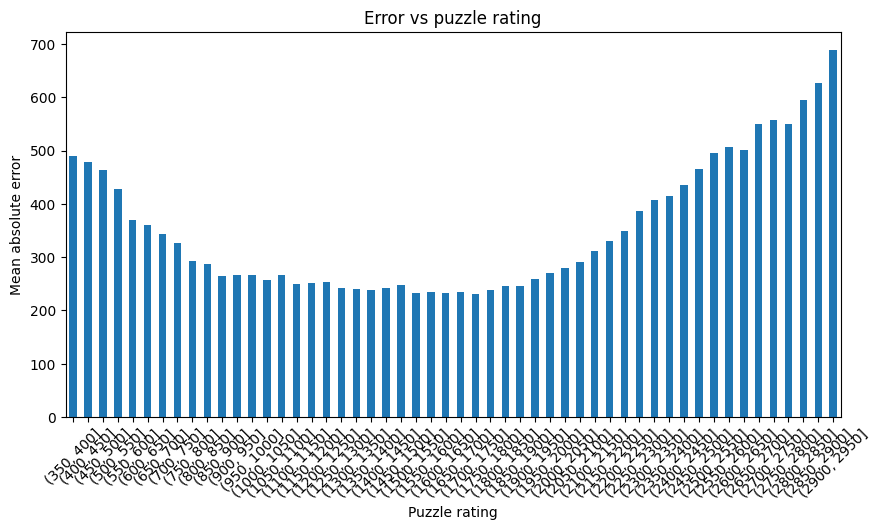

In [62]:
results = pd.DataFrame({
    "true_rating": y_test,
    "pred_rating": y_pred
})

results["abs_error"] = np.abs(results["pred_rating"] - results["true_rating"])
bins = np.arange(300, 3000, 50)

results["rating_bin"] = pd.cut(results["true_rating"], bins)
error_by_rating = results.groupby("rating_bin")["abs_error"].mean()


plt.figure(figsize=(10,5))

error_by_rating.plot(kind="bar")

plt.ylabel("Mean absolute error")
plt.xlabel("Puzzle rating")
plt.title("Error vs puzzle rating")

plt.xticks(rotation=45)

plt.show()

Как видим, модель страдает на тяжёлых задачах, это предсказуемо т.к.
1. в основном задачи сосредоточены вблизи среднего рейтинга
2. на сложных задачах маленькие вероятности успеха, шум на них даёт большой вклад
3. сложность тяжёлых задач часто заключается в сложной идее, которая не связана с числом ходов / фигур и тд 

# Boost

In [99]:
ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

def grad(values):
    a, b = np.polyfit(ratings, values, 1)
    return a

Ещё накидаем от души немножко признаков

In [103]:
dfcut = df

rapid_cols = [
    'success_prob_rapid_1050', 'success_prob_rapid_1150', 'success_prob_rapid_1250',
    'success_prob_rapid_1350', 'success_prob_rapid_1450', 'success_prob_rapid_1550',
    'success_prob_rapid_1650', 'success_prob_rapid_1750', 'success_prob_rapid_1850',
    'success_prob_rapid_1950', 'success_prob_rapid_2050'
]

blitz_cols = [
    'success_prob_blitz_1050', 'success_prob_blitz_1150', 'success_prob_blitz_1250',
    'success_prob_blitz_1350', 'success_prob_blitz_1450', 'success_prob_blitz_1550',
    'success_prob_blitz_1650', 'success_prob_blitz_1750', 'success_prob_blitz_1850',
    'success_prob_blitz_1950', 'success_prob_blitz_2050'
]

all_prob_cols = rapid_cols + blitz_cols
print("already done: ", end="")

# AVG
dfcut['mean_prob_rapid'] = dfcut[rapid_cols].mean(axis=1)
dfcut['mean_prob_blitz'] = dfcut[blitz_cols].mean(axis=1)
print("avg ", end="")

# std
dfcut["std_prob_rapid"] = dfcut[rapid_cols].std(axis=1)
dfcut["std_prob_blitz"] = dfcut[blitz_cols].std(axis=1)
dfcut["range_prob_rapid"] = dfcut[rapid_cols].max(axis=1) - dfcut[rapid_cols].min(axis=1)
dfcut["range_prob_blitz"] = dfcut[blitz_cols].max(axis=1) - dfcut[blitz_cols].min(axis=1)
print("std ", end="")

# Diff players
dfcut['gap_prob_mean'] = dfcut['mean_prob_rapid'] - dfcut['mean_prob_blitz']
print("players ", end="")

# Grad
dfcut["grad_rapid"] = dfcut["success_prob_rapid_2050"] - dfcut["success_prob_rapid_1050"]
dfcut["grad_blitz"] = dfcut["success_prob_blitz_2050"] - dfcut["success_prob_blitz_1050"]
print("grad ", end="")

# Min - max
dfcut["min_prob_rapid"] = dfcut[rapid_cols].min(axis=1)
dfcut["min_prob_blitz"] = dfcut[blitz_cols].min(axis=1)
dfcut["max_prob_rapid"] = dfcut[rapid_cols].max(axis=1)
dfcut["max_prob_blitz"] = dfcut[blitz_cols].max(axis=1)
print("min-max ", end="")

# board info
dfcut["piece_count"] = dfcut["FEN"].apply(count_pieces)
dfcut["solution_length"] = dfcut["Moves"].apply(solution_length)
print("board ", end="")

already done: avg std players grad min-max board 

In [105]:
selected_features = [
    'success_prob_rapid_1150', 'success_prob_rapid_1450', 'success_prob_rapid_2050', 
    'success_prob_blitz_1050', 'success_prob_blitz_1550', 'success_prob_blitz_2050',
    "std_prob_rapid", "std_prob_blitz", 
    "range_prob_rapid", "range_prob_blitz",
    'mean_prob_rapid', 'mean_prob_blitz',
    'gap_prob_mean',
    'grad_rapid', 'grad_blitz',
    "min_prob_rapid", "min_prob_blitz", "max_prob_rapid", "max_prob_blitz",
    "piece_count", "solution_length"
                      ]
print(f"Currently {len(selected_features)} are chosen")

X = dfcut[selected_features]

y = dfcut['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Currently 21 are chosen


In [109]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0.1,
    tree_method="hist",
    device="cuda",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.5738835334777832
MAE: 282.19525146484375
RMSE: 354.9581951617683


<Axes: >

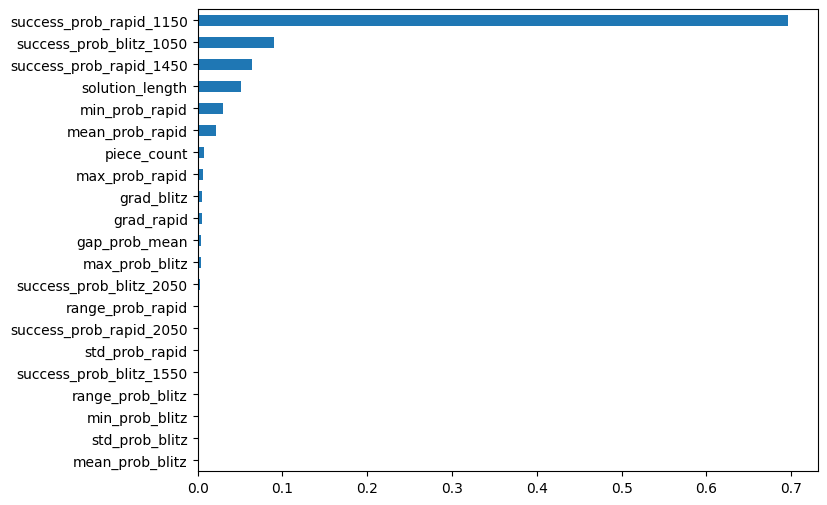

In [108]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values().plot.barh(figsize=(8,6))

# Deep NN

Как было получено в прошлом разделе, вероятностные признаки имеют большие проблемы, будем пробовать оценивать саму позицию напрямую.

In [112]:
dfnn = df[["FEN", "Moves", "Rating"]]
dfnn.head(5)

,FEN,Moves,Rating
0,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1902
1,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1512
2,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1300
3,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1078
4,r4r2/1p3pkp/p5p1/3R1N1Q/3P4/8/P1q2P2/3R2K1 b -...,g6f5 d5c5 c2e4 h5g5 g7h8 g5f6,2877


Для передачи позиции в сеть будем пользоваться 8x8x12 сигналом:

- `0` — white pawn  
- `1` — white knight  
- `2` — white bishop  
- `3` — white rook  
- `4` — white queen  
- `5` — white king  
- `6` — black pawn  
- `7` — black knight  
- `8` — black bishop  
- `9` — black rook  
- `10` — black queen  
- `11` — black king

In [ ]:
piece_map = {
    'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5,
    'p':6,'n':7,'b':8,'r':9,'q':10,'k':11
}

def fen_to_tensor(fen):

    board_tensor = np.zeros((12,8,8), dtype=np.float32)

    board_part = fen.split()[0]
    rows = board_part.split('/')

    for r,row in enumerate(rows):

        c = 0

        for ch in row:

            if ch.isdigit():
                c += int(ch)

            else:
                channel = piece_map[ch]
                board_tensor[channel, r, c] = 1
                c += 1

    return board_tensor